# Financial Literacy CCP (Ψ–QML) — Multi‑Action (Risky‑Share Bins)
**Structural report notebook** — generated on 2025-09-24

This notebook:
1. Loads the two‑wave panel dataset.
2. Runs a **lecture‑style CCP (Ψ–QML)** estimation for a **multi‑action** model with risky‑share bins.
3. Visualizes key diagnostics: observed vs model‑implied CCPs, action shares, and selected transition matrices.

## 1. Setup and data preview

In [1]:
import sys, os, numpy as np, pandas as pd
import matplotlib.pyplot as plt

# sys.path.append('./finlit_psiqml_multi_full')
DATA_PATH = './synthetic_finlit_portfolio.csv'

df = pd.read_csv(DATA_PATH)
print('Rows, Cols:', df.shape)
df.head(10)

Rows, Cols: (3200, 12)


,id,wave,country,female,age,income_eur,liquid_assets_eur,participate_risky,risky_share,risky_assets_eur,safe_assets_eur,literacy_index_z
0,1,1,FI,0,80,75623.673496,2062.062580,1,1.00000,2062.062580,0.000000,-0.143719
1,2,1,IT,0,56,28346.609689,6119.296193,1,1.00000,6119.296193,0.000000,0.754525
2,3,1,NL,1,71,37845.147642,11471.172766,1,1.00000,11471.172766,0.000000,0.754525
3,4,1,FI,1,54,53466.594848,23396.034977,1,1.00000,23396.034977,0.000000,2.551013
4,5,1,ES,0,65,47345.882742,13102.635609,1,1.00000,13102.635609,0.000000,0.754525
5,6,1,DE,1,52,58819.043001,13269.519828,1,1.00000,13269.519828,0.000000,-0.143719
6,7,1,DE,1,82,45681.549392,15244.996641,1,1.00000,15244.996641,0.000000,-1.041963
7,8,1,FI,1,78,53337.467721,3112.186473,1,0.78368,2438.959570,673.226903,-1.041963
8,9,1,DE,1,54,59664.236089,3709.729601,1,1.00000,3709.729601,0.000000,0.754525
9,10,1,FI,1,61,28255.578584,5642.920685,1,1.00000,5642.920685,0.000000,-0.143719


### Quick dataset checks

In [2]:
print(df['wave'].value_counts(dropna=False).sort_index())
print('\nColumns:', list(df.columns))
print('\nParticipation rate by wave:')
print(df.groupby('wave')['participate_risky'].mean())

wave
1    1600
2    1600
Name: count, dtype: int64

Columns: ['id', 'wave', 'country', 'female', 'age', 'income_eur', 'liquid_assets_eur', 'participate_risky', 'risky_share', 'risky_assets_eur', 'safe_assets_eur', 'literacy_index_z']

Participation rate by wave:
wave
1    0.921875
2    0.921875
Name: participate_risky, dtype: float64


## 2. Estimate the model (Ψ–QML)

We follow the lecture’s CCP pipeline:
- Build first‑stage CCPs $\hat P(d\mid x)$ and action‑specific transitions $\hat\Pi(d)$ from wave 1→2.
- Construct structural period utility from the **budget** with CRRA and a literacy‑dependent fixed cost.
- Apply the **Arcidiacono–Miller** operators:
  - $\varphi(P;\theta)\Rightarrow V_\sigma$,
  - $\Lambda(V;\theta)\Rightarrow P$,
  - $\Psi(P;\theta)=\Lambda(\varphi(P;\theta),\theta)$.
- Maximize the QML objective $\sum \log \Psi(\hat P,\theta)$.

In [3]:
from Estimate_QML import estimate_qml
from model_finlit_multi import FinLitMulti

config = {
    'data_path': DATA_PATH,
    'Kx': 3,
    'bins_assets': 4, 'bins_income': 3, 'bins_lit': 3, 'bins_age': 3,
    'smooth': 0.5,
    'beta': 0.95,
    'rf': 0.01,
    'quad_n': 5,
    'maxiter': 100,
    'sigma0': 3.0, 'F0_0': 500.0, 'phi0': 250.0, 'muR0': 0.06, 'sigR0': 0.18,
}

res, model = estimate_qml(config)
print('Converged:', res.success, '|', res.message)
print('theta_hat = (sigma, F0, phi, mu_R, sig_R):', res.x)
print('QML log-likelihood:', -res.fun)

Converged: True | CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
theta_hat = (sigma, F0, phi, mu_R, sig_R): [3.0e+00 5.0e+02 2.5e+02 6.0e-02 1.8e-01]
QML log-likelihood: -2265.1111336558483


## 3. Diagnostics & visualizations

### 3.1 Observed vs model‑implied CCPs (state‑level averages)

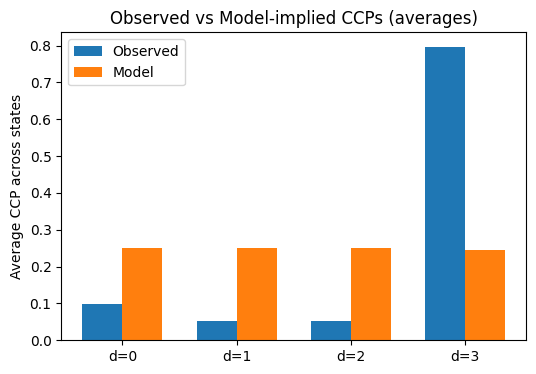

In [4]:
import numpy as np
import matplotlib.pyplot as plt

P_model = model.psi(model.P_hat, res.x)
P_obs = model.P_hat
K = model.Kx + 1

avg_obs = P_obs.mean(axis=0)
avg_mod = P_model.mean(axis=0)

fig = plt.figure(figsize=(6,4))
x = np.arange(K)
w = 0.35
plt.bar(x - w/2, avg_obs, width=w, label='Observed')
plt.bar(x + w/2, avg_mod, width=w, label='Model')
plt.xticks(x, [f'd={j}' for j in range(K)])
plt.ylabel('Average CCP across states')
plt.title('Observed vs Model-implied CCPs (averages)')
plt.legend()
plt.show()

### 3.2 State‑by‑state CCP scatter (one plot per action)

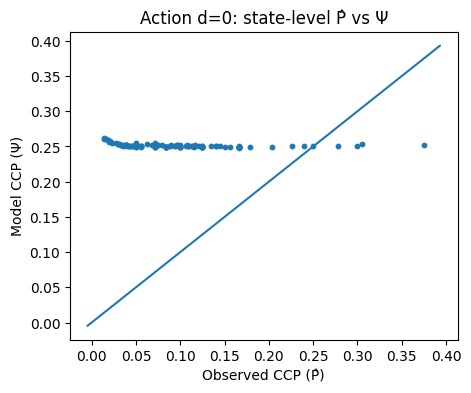

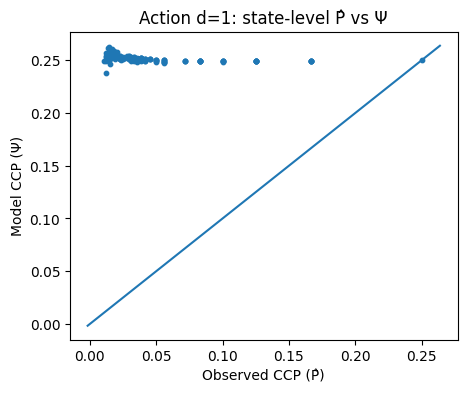

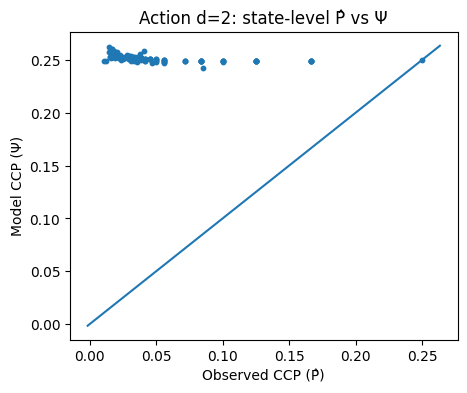

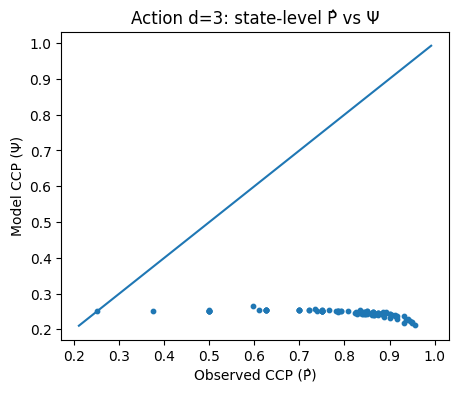

In [5]:
for j in range(K):
    fig = plt.figure(figsize=(5,4))
    plt.scatter(P_obs[:, j], P_model[:, j], s=10)
    plt.xlabel('Observed CCP (P̂)')
    plt.ylabel('Model CCP (Ψ)')
    plt.title(f'Action d={j}: state‑level P̂ vs Ψ')
    mn = min(plt.xlim()[0], plt.ylim()[0])
    mx = max(plt.xlim()[1], plt.ylim()[1])
    plt.plot([mn, mx], [mn, mx])
    plt.show()

### 3.3 Action shares in the data (wave 1)

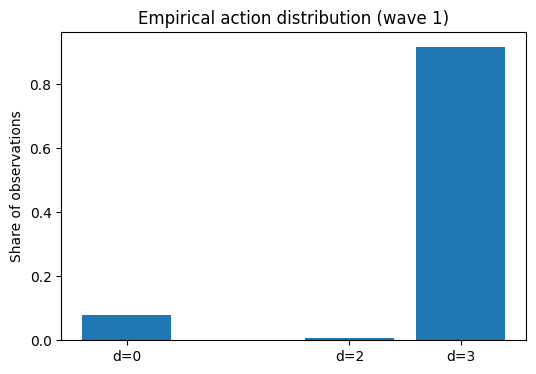

In [6]:
d1 = df[df['wave']==1].copy()
s1 = d1['participate_risky'].astype(int).values
rs = d1['risky_share'].fillna(0.0).clip(0,1).values
rs[s1==0] = 0.0
kx = np.digitize(rs, bins=np.linspace(0,1,model.Kx+1), right=True)
kx = np.clip(kx, 0, model.Kx)
d_multi = np.where(s1==0, 0, kx)

unique, counts = np.unique(d_multi, return_counts=True)
shares = counts / counts.sum()

fig = plt.figure(figsize=(6,4))
plt.bar(unique, shares)
plt.xticks(unique, [f'd={j}' for j in unique])
plt.ylabel('Share of observations')
plt.title('Empirical action distribution (wave 1)')
plt.show()

### 3.4 Transition matrices (heatmaps)

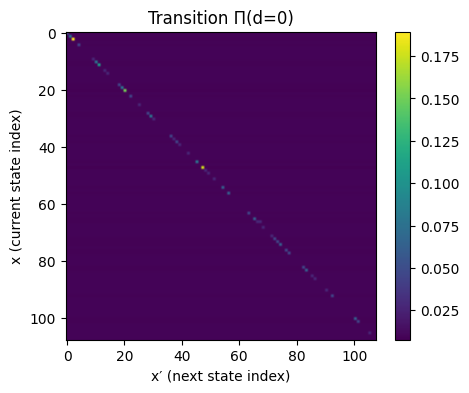

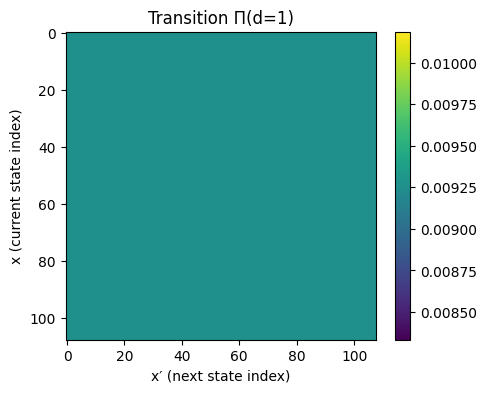

In [7]:
import matplotlib.pyplot as plt

def plot_heat(mat, title):
    fig = plt.figure(figsize=(5,4))
    plt.imshow(mat, aspect='auto')
    plt.colorbar()
    plt.title(title)
    plt.xlabel("x′ (next state index)")
    plt.ylabel('x (current state index)')
    plt.show()

plot_heat(model.Pi[0], 'Transition Π(d=0)')
if model.Kx >= 1:
    plot_heat(model.Pi[1], 'Transition Π(d=1)')

### 3.5 Implied consumption distributions by action (proxies)

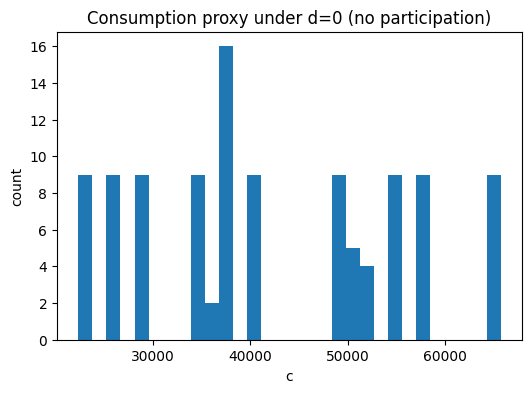

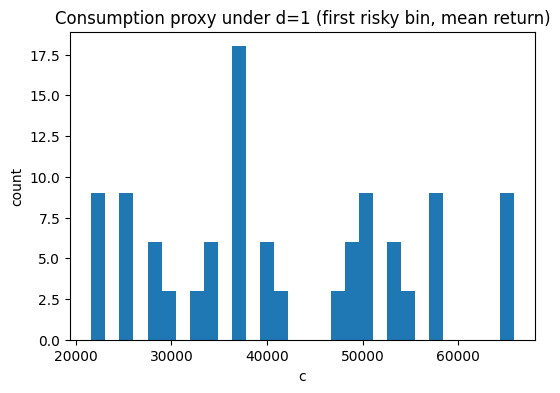

In [8]:
theta = res.x
A = model.state_mids[:,0]; Y = model.state_mids[:,1]; L = model.state_mids[:,2]
a_next0 = model.a_next_bar[:,0]
c0 = Y + A*(1+model.rf) - a_next0

j = min(model.Kx, 1)
xshare = model.share_grid[j-1] if j>0 else 0.0
a_next1 = model.a_next_bar[:, j]
muR, sigR = theta[3], theta[4]
gross = (1-xshare)*(1+model.rf) + xshare*(1+muR)
c1 = Y + A*gross - a_next1 - (theta[1] - theta[2]*L)

fig = plt.figure(figsize=(6,4))
plt.hist(np.clip(c0, 0, None), bins=30)
plt.title('Consumption proxy under d=0 (no participation)')
plt.xlabel('c')
plt.ylabel('count')
plt.show()

fig = plt.figure(figsize=(6,4))
plt.hist(np.clip(c1, 0, None), bins=30)
plt.title('Consumption proxy under d=1 (first risky bin, mean return)')
plt.xlabel('c')
plt.ylabel('count')
plt.show()

## 4. Notes
- Structural utility from the budget (CRRA) + literacy‑dependent fixed cost $F(L)=F_0-\phi L$.
- Risky share as part of the **discrete action** set.
- Action‑specific empirical transitions with Laplace smoothing.
- CCP estimation via the lecture’s **Ψ operator** and QML objective.
- For robustness: vary `Kx`, bin counts, and quadrature nodes; compare the CCP plots.